In [4]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS'] = '1'

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import pickle
import re

from util import MAX_DD, turnover, generate_single_sort_latex_table, generate_double_sort_latex_table

In [5]:
def summarize_sorted_portfolios(horizon='12month',
                                strategy='single_sort',
                                strategy_params=None,
                                stock_info=None):
    """
    Summarize realized returns of sorted portfolios with High–Low (H–L) spreads, in percentage format.

    - single_sort: deciles sorted by predicted returns.
        → Report realized returns only (mean actual returns by decile)
          and H–L spread (10th − 1st decile), all multiplied by 100.
    - double_sort: 5×5 portfolios sorted by predicted return within consensus quintiles.
        → Report realized returns only (mean actual returns by [cons_rank, pred_rank])
          and H–L spreads both row-wise (col_5 − col_1) and column-wise (row_5 − row_1), all multiplied by 100.

    Returns
    -------
    summary_dict : dict or pd.DataFrame
        For single_sort:
            DataFrame [deciles + H–L × λ columns of realized returns (%)]
        For double_sort:
            {λ: DataFrame [5×5 realized return matrix + H–L row and column, in %]}
    """
    summary_dict = {}
    target_lambdas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    if strategy == 'single_sort':
        target_lambdas.append(0.0)

    for file in os.listdir('../results'):
        if not file.startswith(horizon) or not file.endswith('.pickle'):
            continue
        lam = float(file.split(f'{horizon}_')[1].split('.pickle')[0])
        if lam not in target_lambdas:
            continue

        # Load model output
        path = os.path.join('../results', file)
        with open(path, 'rb') as f:
            output = pickle.load(f)

        # Forecasts (predicted returns)
        forecast = output['forecast_target']
        forecast.columns = ['date', 'permno', 'forecast']
        forecast['date'] = pd.to_datetime(forecast['date'])

        # Use one-month realized returns for consistency
        if horizon != '1month':
            one_path = os.path.join('../results', f'1month_{lam}.pickle')
            if os.path.exists(one_path):
                with open(one_path, 'rb') as f1:
                    out1 = pickle.load(f1)
                actual = out1['actual_target']
            else:
                actual = output['actual_target']
        else:
            actual = output['actual_target']

        actual.columns = ['date', 'permno', 'actual']
        actual['date'] = pd.to_datetime(actual['date'])

        # Merge realized and predicted returns
        merged = pd.merge(actual, forecast, on=['date', 'permno']).dropna()
        if stock_info is not None:
            merged = pd.merge(merged, stock_info, on=['permno'], how='left')

        # ===== Double-sort requires consensus variable =====
        if strategy == 'double_sort':
            cons = output['forecast_concept']
            cons.columns = ['date', 'permno', 'EPS forecast revision', 'Change in recommendation',
                            'Change in Forecast and Accrual', 'Long-vs-short EPS forecasts',
                            'Analyst earnings per share', 'EPS Forecast Dispersion',
                            'Earnings forecast revisions', 'Analyst Value', 'Analyst Optimism']
            cons_var = strategy_params.get('cons_var', 'Analyst earnings per share')
            merged = pd.merge(merged, cons[['date', 'permno', cons_var]],
                              on=['date', 'permno'], how='left')

        # ===== Portfolio formation =====
        real_means = []
        for _, group in merged.groupby('date'):
            if strategy == 'single_sort':
                try:
                    group['pred_rank'] = pd.qcut(group['forecast'], 10, labels=False, duplicates='drop') + 1
                except ValueError:
                    continue
                real_mean = group.groupby('pred_rank')['actual'].mean()
                real_means.append(real_mean)

            elif strategy == 'double_sort':
                cons_var = strategy_params.get('cons_var', 'Analyst earnings per share')
                try:
                    group['cons_rank'] = pd.qcut(group[cons_var], 5, labels=False, duplicates='drop') + 1
                except ValueError:
                    continue

                # Within each consensus quintile, sort into predicted quintiles
                group['pred_rank'] = np.nan
                for c in group['cons_rank'].dropna().unique():
                    sub_idx = group[group['cons_rank'] == c].index
                    sub = group.loc[sub_idx]
                    try:
                        group.loc[sub_idx, 'pred_rank'] = pd.qcut(sub['forecast'], 5, labels=False, duplicates='drop') + 1
                    except ValueError:
                        continue

                temp = group.dropna(subset=['cons_rank', 'pred_rank'])
                real_mean = temp.groupby(['cons_rank', 'pred_rank'])['actual'].mean().unstack()
                real_means.append(real_mean)

        # ===== Aggregate across time =====
        if strategy == 'single_sort':
            real_df = pd.concat(real_means, axis=1).mean(axis=1) * 100  # ← convert to %
            hl_value = real_df.loc[real_df.index.max()] - real_df.loc[real_df.index.min()]
            real_df.loc['H–L'] = hl_value
            real_df.name = f'{lam:.1f}'
            summary_dict[lam] = real_df

        else:  # double-sort
            full_idx = pd.Index(range(1, 6), name='cons_rank')
            full_cols = pd.Index(range(1, 6), name='pred_rank')
            matrices = [r.reindex(index=full_idx, columns=full_cols) for r in real_means]
            real_matrix = pd.concat(matrices).groupby(level=0).mean() * 100  # ← convert to %

            # Add H–L spreads (row- and column-wise)
            real_matrix['H–L'] = real_matrix[5] - real_matrix[1]
            hl_row = real_matrix.loc[5] - real_matrix.loc[1]
            hl_row.name = 'H–L'
            real_matrix = pd.concat([real_matrix, pd.DataFrame([hl_row])])

            real_matrix.index.name = 'Consensus Quintile'
            summary_dict[lam] = real_matrix

    # ===== Combine outputs =====
    if strategy == 'single_sort':
        result = pd.concat(summary_dict.values(), axis=1)
        result.columns = [f'{lam:.1f}' for lam in sorted(summary_dict.keys())]
        result.index.name = 'Decile'
    else:
        result = summary_dict

    return result

In [16]:
def generate_portfolio(curr_returns, strategy='single_sort', params=None):
    """
    Generate portfolio based on different strategies
    
    Parameters:
    -----------
    curr_returns : pd.DataFrame
        DataFrame containing returns and other metrics for current timestamp
    strategy : str
        Portfolio generation strategy ('single_sort', 'double_sort', etc.)
    params : dict
        Strategy-specific parameters (quantiles, consensus variable, etc.)
    
    Returns:
    --------
    tuple : (long_posit, short_posit) - Series of permno for long and short positions
    """
    if params is None:
        params = {}
    
    if strategy == 'single_sort':
        # Default quantiles for single sort
        upper_quantile = params.get('upper_quantile', 0.9)
        lower_quantile = params.get('lower_quantile', 0.1)
        
        long_cut = curr_returns.quantile(upper_quantile)['forecast']
        short_cut = curr_returns.quantile(lower_quantile)['forecast']
        long_mask = curr_returns['forecast'] >= long_cut
        short_mask = curr_returns['forecast'] <= short_cut
        
    elif strategy == 'double_sort':
        # Separate quantiles for consensus and returns
        upper_quantile_cons = params.get('upper_quantile_cons', 0.75)
        lower_quantile_cons = params.get('lower_quantile_cons', 0.25)
        upper_quantile_ret = params.get('upper_quantile_ret', 0.75)
        lower_quantile_ret = params.get('lower_quantile_ret', 0.25)
        sorting_sign = params.get('sorting_sign', 'positive')
        cons_var = params.get('cons_var', 'Analyst earnings per share')
        
        # First: Sort with consensus
        if (sorting_sign == 'positive'):
            long_con = curr_returns.quantile(upper_quantile_cons)[cons_var]
            short_con = curr_returns.quantile(lower_quantile_cons)[cons_var]
            
            long_mask_con = curr_returns[cons_var] >= long_con
            short_mask_con = curr_returns[cons_var] <= short_con
        elif (sorting_sign == 'negative'):
            long_con = curr_returns.quantile(lower_quantile_cons)[cons_var]
            short_con = curr_returns.quantile(upper_quantile_cons)[cons_var]
            
            long_mask_con = curr_returns[cons_var] <= long_con
            short_mask_con = curr_returns[cons_var] >= short_con

        long_posit_con = curr_returns[long_mask_con]['permno']
        short_posit_con = curr_returns[short_mask_con]['permno']

        # Second: Sort with forecasts
        long_fore = curr_returns[curr_returns['permno'].isin(long_posit_con)].quantile(upper_quantile_ret)['forecast']
        short_fore = curr_returns[curr_returns['permno'].isin(short_posit_con)].quantile(lower_quantile_ret)['forecast']
        
        long_mask = curr_returns['permno'].isin(long_posit_con) & (curr_returns['forecast'] >= long_fore)
        short_mask = curr_returns['permno'].isin(short_posit_con) & (curr_returns['forecast'] <= short_fore)
    elif strategy == 'screening':
        # Screening strategy: first filter by consensus quantile threshold, then single sort by forecast
        cons_var = params.get('cons_var', 'Analyst earnings per share')
        cons_ref = params.get('cons_ref', 0.5)  # Quantile threshold for consensus variable (0-1)
        sorting_sign = params.get('sorting_sign', 'positive')
        upper_quantile = params.get('upper_quantile', 0.9)
        lower_quantile = params.get('lower_quantile', 0.1)
        
        # First: Screen with consensus quantile threshold
        cons_threshold = curr_returns[cons_var].quantile(cons_ref)
        
        if sorting_sign == 'positive':
            long_mask_con = curr_returns[cons_var] >= cons_threshold
            short_mask_con = curr_returns[cons_var] <= cons_threshold
        elif sorting_sign == 'negative':
            long_mask_con = curr_returns[cons_var] <= cons_threshold
            short_mask_con = curr_returns[cons_var] >= cons_threshold
        else:
            raise ValueError(f"Unknown sorting_sign: {sorting_sign}")
        
        # Get screened groups
        long_screened = curr_returns[long_mask_con]
        short_screened = curr_returns[short_mask_con]
        
        # Second: Single sort on forecast within each screened group
        # Create boolean masks for the entire curr_returns dataframe
        long_mask = pd.Series(False, index=curr_returns.index)
        short_mask = pd.Series(False, index=curr_returns.index)
        
        if len(long_screened) > 0:
            long_fore = long_screened.quantile(upper_quantile)['forecast']
            long_screened_mask = long_screened['forecast'] >= long_fore
            long_mask[long_screened_mask.index] = long_screened_mask.values
        
        if len(short_screened) > 0:
            short_fore = short_screened.quantile(lower_quantile)['forecast']
            short_screened_mask = short_screened['forecast'] <= short_fore
            short_mask[short_screened_mask.index] = short_screened_mask.values
    else:
        raise ValueError(f"Unknown strategy: {strategy}")
    
    long_posit = curr_returns[long_mask]['permno']
    short_posit = curr_returns[short_mask]['permno']
    
    return long_posit, short_posit

In [7]:
def calculate_portfolio_weights(curr_returns, long_posit, short_posit, weight_type='value'):
    """
    Calculate portfolio weights based on different weighting schemes
    
    Parameters:
    -----------
    curr_returns : pd.DataFrame
        DataFrame containing returns and other metrics for current timestamp
    long_posit : pd.Series
        Series of permno for long positions
    short_posit : pd.Series
        Series of permno for short positions
    weight_type : str
        Weighting scheme ('value', 'equal', etc.)
        
    Returns:
    --------
    tuple : (portfolio_weight, portfolio_return)
    """
    if weight_type == 'value':
        # Value-weighted portfolio
        long_total = curr_returns[curr_returns['permno'].isin(long_posit)]['Size'].sum()
        short_total = curr_returns[curr_returns['permno'].isin(short_posit)]['Size'].sum()
        long_weight = curr_returns[curr_returns['permno'].isin(long_posit)]['Size']/long_total
        short_weight = -curr_returns[curr_returns['permno'].isin(short_posit)]['Size']/short_total
    
    elif weight_type == 'equal':
        # Equal-weighted portfolio
        long_weight = pd.Series(1/len(long_posit), index=long_posit.index)
        short_weight = pd.Series(-1/len(short_posit), index=short_posit.index)
    
    else:
        raise ValueError(f"Unknown weight type: {weight_type}")
    
    # Calculate portfolio weights and returns
    portfolio_weight = pd.concat([long_weight, short_weight])
    portfolio_weight.name = 'weight'
    portfolio_weight = curr_returns.join(portfolio_weight, how='left')[['date', 'permno', 'weight']].fillna(0).set_index('date')
    
    # Calculate returns
    long_return = curr_returns[curr_returns['permno'].isin(long_posit)]['actual'].values * long_weight
    short_return = curr_returns[curr_returns['permno'].isin(short_posit)]['actual'].values * short_weight
    portfolio_return = pd.concat([long_return, short_return]).sum()
    
    return portfolio_weight, portfolio_return

In [14]:
def plot_portfolio_performance(horizon='12month', strategy='single_sort', 
                             weight_type='value', strategy_params=None, 
                             risk_free=None, stock_info=None, snp_500=None,
                             transaction_cost: float = 0.0):
    """
    Plot portfolio performance with optional transaction cost adjustment.

    Parameters
    ----------
    horizon : str
        Evaluation horizon, e.g., '12month'.
    strategy : str
        Portfolio construction strategy, e.g., 'single_sort'.
    weight_type : str
        Weighting scheme used for portfolio formation.
    strategy_params : dict
        Strategy-specific parameters.
    risk_free : pd.DataFrame, optional
        Risk-free rate (not used but kept for compatibility).
    stock_info : pd.DataFrame
        Firm-level information merged into the returns dataset.
    snp_500 : pd.DataFrame
        Benchmark return series; includes 'date' and 'return'.
    transaction_cost : float, optional
        Proportional transaction cost applied per unit of turnover.
        Net return formula: r_t(net) = r_t(gross) - transaction_cost * turnover_t.

    Returns
    -------
    portfolio_summary : dict
        Dictionary containing net log returns, weights, and individual returns.
    """

    # Matplotlib style settings
    plt.rcParams.update({
        'font.family': 'Times New Roman',
        'font.size': 11,
        'axes.linewidth': 0.8,
        'axes.spines.top': False,
        'axes.spines.right': False,
        'xtick.major.size': 4,
        'ytick.major.size': 4,
        'xtick.major.width': 0.8,
        'ytick.major.width': 0.8,
        'lines.linewidth': 1,
        'grid.alpha': 0.3,
        'grid.linewidth': 0.5
    })
    
    # Output container
    portfolio_summary = dict()
    portfolio_summary['return'] = pd.DataFrame()
    portfolio_summary['weight'] = dict()
    portfolio_summary['returns'] = dict()

    # Store final cumulative returns for legend sorting
    final_returns = {}
    
    fig, ax = plt.subplots(figsize=(20, 8))

    # Target lambda values to plot
    target_lambdas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    if strategy == 'single_sort':
        target_lambdas.append(0.0)

    colors = plt.cm.rainbow(np.linspace(0, 1, len(target_lambdas)))
    color_idx = 0

    # Loop through result files
    for file in os.listdir('../results'):
        if file.startswith(horizon) and file.endswith('.pickle'):
            weight_lambda = float(file.split(f'{horizon}_')[1].split('.pickle')[0])
            if weight_lambda not in target_lambdas:
                continue

            # Load prediction results
            path = os.path.join('../results', file)
            with open(path, 'rb') as f:
                output = pickle.load(f)

            # Load forecast signal
            forecast = output['forecast_target']
            forecast.columns = ['date', 'permno', 'forecast']
            forecast['date'] = pd.to_datetime(forecast['date'])

            # Load actual returns
            if horizon != '1month':
                one_path = os.path.join('../results', f'1month_{weight_lambda}.pickle')
                if os.path.exists(one_path):
                    with open(one_path, 'rb') as f1:
                        actual = pickle.load(f1)['actual_target']
                else:
                    actual = output['actual_target']
            else:
                actual = output['actual_target']

            actual.columns = ['date', 'permno', 'actual']
            actual['date'] = pd.to_datetime(actual['date'])

            # Merge forecast and actuals
            returns = pd.merge(actual, forecast, on=['date', 'permno']).dropna()

            # If double sort
            if strategy == 'double_sort' or strategy == 'screening':
                consensuses = output['forecast_concept']
                consensuses.columns = [
                    'date', 'permno',
                    'EPS forecast revision', 'Change in recommendation',
                    'Change in Forecast and Accrual', 'Long-vs-short EPS forecasts',
                    'Analyst earnings per share', 'EPS Forecast Dispersion',
                    'Earnings forecast revisions', 'Analyst Value', 'Analyst Optimism'
                ]
                cons_var = strategy_params.get('cons_var', 'Analyst earnings per share')

                returns = pd.merge(
                    returns,
                    consensuses[['date', 'permno', cons_var]],
                    on=['date', 'permno'],
                    how='left',
                    validate='many_to_one'
                )

            # Merge stock characteristics
            returns = pd.merge(returns, stock_info, how='left')

            # Containers
            portfolio_returns = []
            individual_returns = pd.DataFrame()
            portfolio_weights = pd.DataFrame()

            # Loop by date snapshot
            for date, curr in returns.groupby('date'):
                # Save individual log returns
                individual_returns = pd.concat(
                    [individual_returns, curr[['date', 'permno', 'actual']].set_index('date')]
                )

                # Portfolio construction
                long_pos, short_pos = generate_portfolio(
                    curr,
                    strategy=strategy,
                    params=strategy_params
                )

                # Weight and return calculation
                w, r = calculate_portfolio_weights(
                    curr,
                    long_pos,
                    short_pos,
                    weight_type=weight_type
                )

                portfolio_weights = pd.concat([portfolio_weights, w])
                portfolio_returns.append(r)

            # ----------------------------
            # Transaction cost adjustment
            # ----------------------------
            if transaction_cost > 0.0:
                # Convert log returns to arithmetic for turnover calculation
                returns_tc = individual_returns.copy()
                returns_tc['actual'] = np.exp(returns_tc['actual']) - 1

                # Compute turnover for T-1 periods
                turnover_list = turnover(returns_tc, portfolio_weights)

                # Prepend 0 for the first period (no turnover)
                tc_array = np.array([0.0] + turnover_list)

                # Align lengths
                T = len(portfolio_returns)
                if len(tc_array) < T:
                    tc_array = np.concatenate([tc_array, np.zeros(T - len(tc_array))])
                elif len(tc_array) > T:
                    tc_array = tc_array[:T]

                gross = np.array(portfolio_returns)
                net = gross - transaction_cost * tc_array

                portfolio_returns = list(net)

            # Build cumulative return series
            portfolio = pd.DataFrame(index=returns['date'].unique())
            portfolio['return'] = portfolio_returns
            portfolio[f'$\\lambda=${weight_lambda}'] = portfolio['return'].cumsum()

            final_returns[f'$\\lambda=${weight_lambda}'] = portfolio[f'$\\lambda=${weight_lambda}'].iloc[-1]

            # Plot curve
            ax.plot(
                portfolio.index,
                portfolio[f'$\\lambda=${weight_lambda}'],
                color=colors[color_idx % len(colors)],
                linewidth=1
            )
            color_idx += 1

            # Save into summary dictionary
            portfolio_summary['return'][weight_lambda] = portfolio_returns
            portfolio_summary['weight'][weight_lambda] = portfolio_weights
            portfolio_summary['returns'][weight_lambda] = individual_returns

    # ----------------------------
    # Benchmark processing
    # ----------------------------
    dates = pd.to_datetime(sorted(returns['date'].unique()))
    portfolio_summary['return']['date'] = dates

    snp_aligned = snp_500.copy()
    snp_aligned['date'] = pd.to_datetime(snp_aligned['date'])
    snp_aligned = snp_aligned.set_index('date').reindex(dates)

    portfolio_summary['return']['S&P 500'] = snp_aligned['return'].values

    snp_plot = snp_aligned['return'].fillna(0).cumsum()
    final_returns['S&P 500'] = snp_plot.iloc[-1]

    ax.plot(snp_plot.index, snp_plot.values, linestyle='--', color='black', linewidth=1)

    # Legend
    ax.legend(
        [label for label in final_returns.keys()],
        title='Portfolios',
        title_fontsize=25,
        bbox_to_anchor=(1.05, 1),
        loc='upper left',
        fontsize=25
    )

    ax.set_ylabel('Cumulative Log Returns', fontsize=30)
    ax.set_xlabel('Year', fontsize=30)
    ax.tick_params(axis='x', labelsize=23)
    ax.tick_params(axis='y', labelsize=23)
    ax.grid()

    plt.tight_layout()
    plt.show()
    plt.close()

    return portfolio_summary


In [9]:
def load_other_data():
    # Risk free rates to calculate excess returns

    welch_goyal = pd.read_csv('../data/raw/welch_goyal_raw.csv')
    welch_goyal['yyyymm'] = pd.to_datetime(welch_goyal['yyyymm'], format = '%Y%m')
    welch_goyal = welch_goyal.rename(columns={'yyyymm':'date'})
    risk_free = welch_goyal[['date', 'Rfree']]

    # SNP500 log returns for benchmark

    snp_500 = welch_goyal[['date', 'Index']].copy()
    snp_500.loc[:, 'return'] = np.log(snp_500['Index']) - np.log(snp_500['Index'].shift(1))
    snp_500 = snp_500.drop('Index', axis=1)

    # Filter the data to match portfolio period
    start_date = pd.to_datetime('2013-01-01')
    end_date = pd.to_datetime('2023-01-01')
    snp_500 = snp_500[(snp_500['date'] >= start_date) & (snp_500['date'] <= end_date)]

    # Stock price and market cap for value-weighted portfolios

    CZD = pd.read_csv('../data/raw/open_source_asset_pricing.csv')

    stock_info = CZD[['date', 'permno', 'Size', 'Price']]

    temp_dates = pd.to_datetime(stock_info['date'])
    stock_info = pd.DataFrame({
        'date': temp_dates,
        **stock_info.drop('date', axis=1)
    })

    return risk_free, snp_500, stock_info

In [20]:
def calculate_portfolio_metrics(portfolio_summary):
    """
    Calculate portfolio performance evaluation metrics
    
    Parameters:
    -----------
    portfolio_summary : dict
        Dictionary containing portfolio returns, weights, and individual returns
        
    Returns:
    --------
    portfolio_analysis : pd.DataFrame
        DataFrame containing performance metrics for each portfolio
    """
    portfolio_analysis = pd.DataFrame()
    portfolio_return = portfolio_summary['return'].drop('date', axis=1)

    # (1) Monthly mean moments (from monthly log returns)
    portfolio_analysis['mean return'] = portfolio_return.mean()
    portfolio_analysis['std'] = portfolio_return.std()

    # (2) Cumulative log return
    cumsum = portfolio_return.cumsum()
    portfolio_analysis['cumulative return'] = cumsum.iloc[-1]

    # (3) Annualized Sharpe ratio (arithmetic)
    annualized_return = np.exp(portfolio_return.mean() * 12) - 1
    annualized_volatility = portfolio_return.std() * np.sqrt(12)
    portfolio_analysis['Sharpe'] = annualized_return / annualized_volatility

    # (4) Maximum 1-month loss (arithmetic)
    portfolio_analysis['max 1M loss'] = (1 - np.exp(portfolio_return.min())) * 100

    # (5) Maximum Drawdown (arithmetic)
    wealth = np.exp(portfolio_return.cumsum())  # convert log to cumulative wealth
    portfolio_analysis['max DD'] = wealth.apply(MAX_DD) * 100

    # (6) Portfolio Turnover (monthly mean)
    portfolio_turnover = pd.Series(dtype=float)

    for weight_key in portfolio_summary['weight']:
        returns = portfolio_summary['returns'][weight_key].copy()
        weights = portfolio_summary['weight'][weight_key].copy()

        # Convert log returns → arithmetic
        returns['actual'] = np.exp(returns['actual']) - 1

        # Compute mean turnover across rebalancing periods
        portfolio_turnover[weight_key] = np.mean(turnover(returns, weights))

    portfolio_analysis['turnover'] = portfolio_turnover * 100

    return portfolio_analysis

In [11]:
single_sort_results = summarize_sorted_portfolios(horizon='12month', strategy='single_sort')
single_sort_results

,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
Decile,,,,,,,,,,,
1,-0.358802,-0.696339,-0.782697,-0.961845,-0.880930,-0.915223,-0.907433,-0.933309,-0.916844,-0.961001,-0.943176
2,-0.265983,-0.238052,-0.264329,-0.235406,-0.250041,-0.225142,-0.290324,-0.291004,-0.325720,-0.273906,-0.311658
3,0.061033,-0.034462,-0.107424,-0.032261,-0.164960,-0.164058,-0.029310,0.046663,0.027361,-0.057126,-0.066325
4,0.138133,0.134467,0.219404,0.202387,0.298763,0.313524,0.292825,0.216380,0.299728,0.251626,0.266734
5,0.204796,0.390932,0.414775,0.334707,0.345642,0.359676,0.407103,0.413464,0.353868,0.391173,0.402412
6,0.296100,0.355930,0.511450,0.515853,0.516721,0.359700,0.317640,0.273072,0.289598,0.367325,0.340585
7,0.468405,0.517209,0.480038,0.546952,0.407457,0.488046,0.498943,0.488562,0.435685,0.436523,0.505751
8,0.638198,0.721556,0.613670,0.619328,0.794724,0.793588,0.722381,0.846326,0.853863,0.838037,0.791175
9,0.773462,0.775036,0.876727,0.905474,0.849348,0.931350,0.930193,0.794994,0.866003,0.894520,0.853772


In [12]:
latex_table = generate_single_sort_latex_table(single_sort_results)
print(latex_table)

\begin{table}[htbp]
    \centering
    \small
    \renewcommand{\arraystretch}{1.3}
    \setlength{\tabcolsep}{6pt}

    \caption{Realized monthly returns of single-sorted portfolios across $\lambda$. \\
    Each panel reports mean monthly realized returns (in percentage points) for monthly rebalanced decile portfolios, 
    formed by sorting stocks on CB-APM-predicted annual returns.
    The bottom row (H--L) represents the spread between the highest- and lowest-decile portfolios.}
    \label{tab:single-sort}

    \vspace{0.2cm}
    
\begin{tabular*}{\textwidth}{@{\extracolsep{\fill}} l S[table-format=-1.4] S[table-format=-1.4] S[table-format=-1.4] S[table-format=-1.4] S[table-format=-1.4] S[table-format=-1.4] }
\toprule
{\small $\lambda$} & \small 0.0 & \small 0.1 & \small 0.2 & \small 0.3 & \small 0.4 & \small 0.5 \\
\midrule
Low & -0.36 & -0.70 & -0.78 & -0.96 & -0.88 & -0.92 \\
2 & -0.27 & -0.24 & -0.26 & -0.24 & -0.25 & -0.23 \\
3 & 0.06 & -0.03 & -0.11 & -0.03 & -0.16 & -0.16 \\

In [8]:
double_sort_results = summarize_sorted_portfolios(horizon='12month', strategy='double_sort', strategy_params={'cons_var': 'Analyst earnings per share'})
double_sort_results

{0.1: pred_rank                  1         2         3         4         5       H–L
 Consensus Quintile                                                            
 1                  -0.647131 -0.433931  0.041696  0.675627  1.473315  2.120446
 2                  -0.307621  0.027040  0.382009  0.304078  0.632197  0.939818
 3                  -0.274255  0.388769  0.350843  0.395141  0.690452  0.964706
 4                  -0.112669  0.171798  0.449099  0.328405  0.863778  0.976447
 5                   0.282228  0.447151  0.455937  0.695415  0.809576  0.527348
 H–L                 0.929359  0.881082  0.414240  0.019788 -0.663739 -1.593098,
 0.2: pred_rank                  1         2         3         4         5       H–L
 Consensus Quintile                                                            
 1                  -0.727096 -0.406321 -0.041071  0.668018  1.540938  2.268034
 2                  -0.335857  0.010158  0.384016  0.535478  0.616202  0.952059
 3                  -0.269817

In [9]:
latex_table = generate_double_sort_latex_table(double_sort_results, 'FEPS')
print(latex_table)

\begin{small}
\renewcommand{\arraystretch}{0.7}
\setlength{\LTleft}{0pt}
\setlength{\LTright}{0pt}


\begin{longtable}{@{\extracolsep{\fill}} p{1.6cm} *{6}{S[table-format=-1.2, table-column-width=1.5cm]}}

\caption{Realized monthly returns of out-of-sample double-sorted portfolios across $\lambda$.\\
Each panel reports mean monthly realized returns (in percentage points) for monthly rebalanced 5×5 portfolios 
sorted by the approximated \textit{FEPS} (rows) and predicted annual returns ($E[R]$, columns), independently.
H--L denotes the high–minus–low spread across the corresponding dimension.}\label{tab:double-sort} \\
    
\endfirsthead

\multicolumn{7}{c}{\textbf{Table \thetable} Realized returns of double-sorted portfolios (cont'd)}\\
\midrule
\endhead

\endfoot

\endlastfoot

\multicolumn{7}{c}{\textbf{Panel:} $\bm{\lambda = 0.1}$} \\[3pt]
\midrule
& \multicolumn{5}{c}{\small {$E_t[R_{i,t+h}]$}} & \\
\cmidrule(lr){2-6}
{\small $E_t[{FEPS}_{i, t}]$} & Low & 2 & 3 & 4 & High & H\text{

In [10]:
risk_free, snp_500, stock_info = load_other_data()

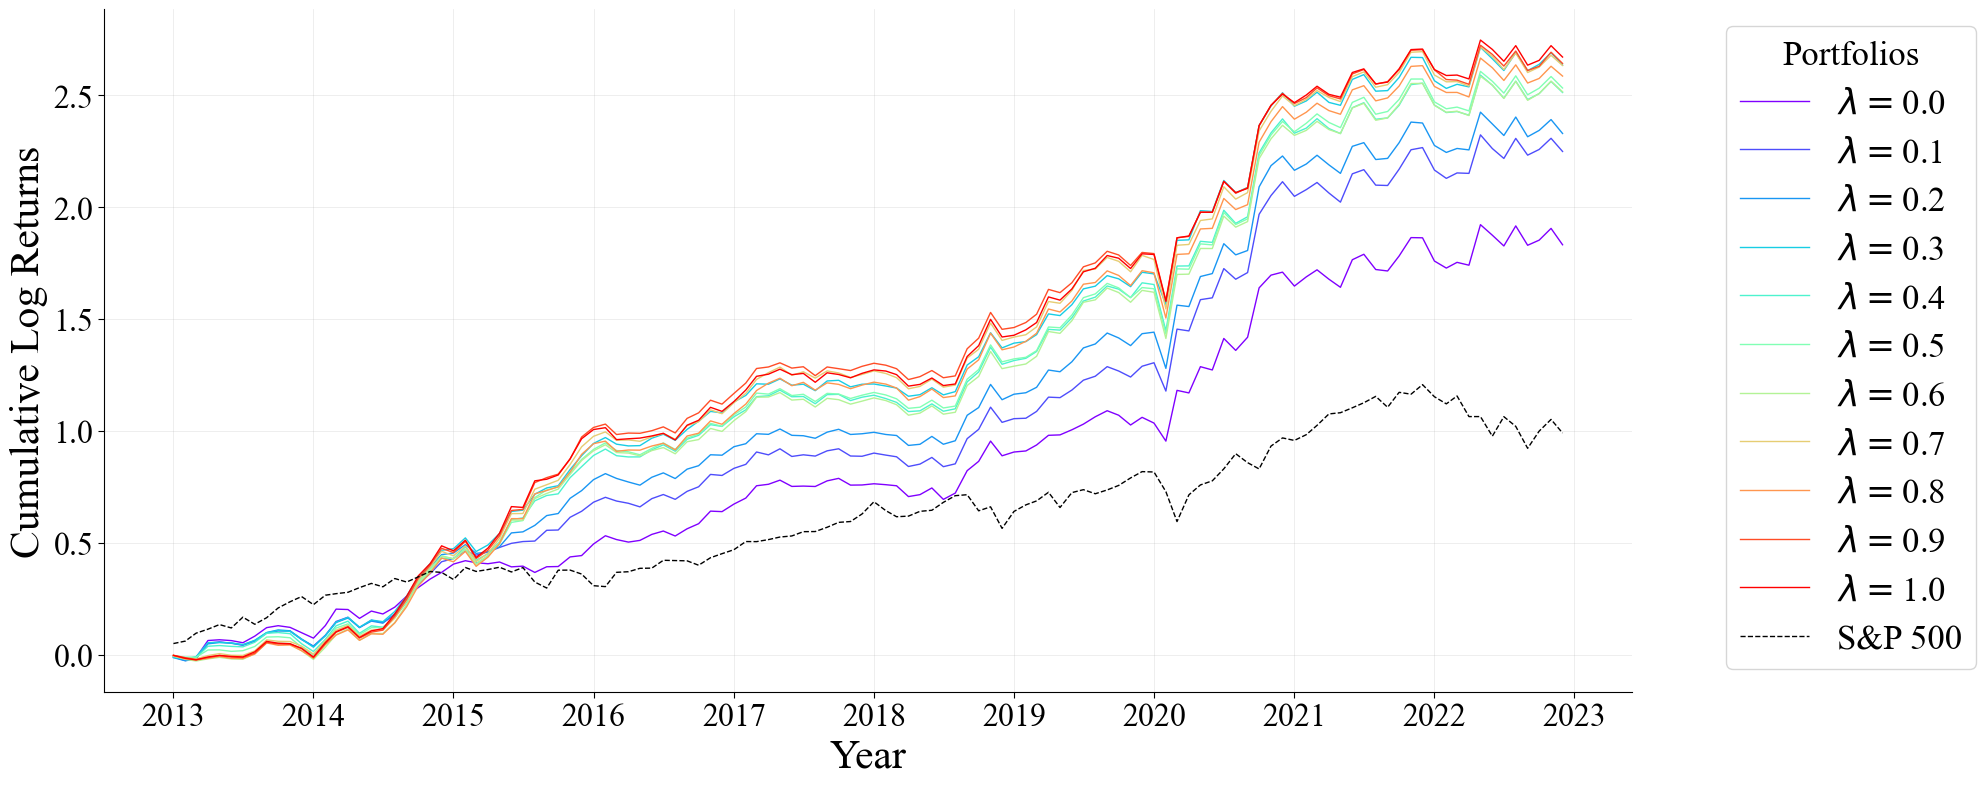

In [16]:
portfolio_summary_12_single = plot_portfolio_performance(
    horizon='12month',
    strategy='single_sort',
    strategy_params={
        'upper_quantile': 0.9,
        'lower_quantile': 0.1
    },
    weight_type='value',
    risk_free=risk_free, snp_500=snp_500, stock_info=stock_info
)

In [19]:
portfolio_analysis_12_single = calculate_portfolio_metrics(portfolio_summary_12_single)
portfolio_analysis_12_single

,mean return,std,cumulative return,Sharpe,max 1M loss,max DD,turnover
0.0,0.015265,0.052771,1.831817,1.099725,9.865380,12.733747,58.286652
0.1,0.018740,0.057332,2.248825,1.269737,11.896484,12.850533,58.103473
0.2,0.019410,0.059950,2.329233,1.262967,14.945767,14.945767,58.833569
0.3,0.021956,0.060536,2.634718,1.437463,12.785755,13.416143,60.901628
0.4,0.020937,0.063176,2.512475,1.305134,18.628544,19.251865,61.096150
0.5,0.021105,0.063177,2.532543,1.316930,18.247561,20.188032,60.651463
0.6,0.020963,0.063554,2.515590,1.299210,18.662176,20.182360,60.996226
0.7,0.021943,0.064250,2.633174,1.353472,19.822190,21.279967,60.276922
0.8,0.021548,0.063118,2.585809,1.349612,18.316914,19.080509,60.614779
0.9,0.022019,0.063601,2.642332,1.372685,18.877070,19.713983,61.237938


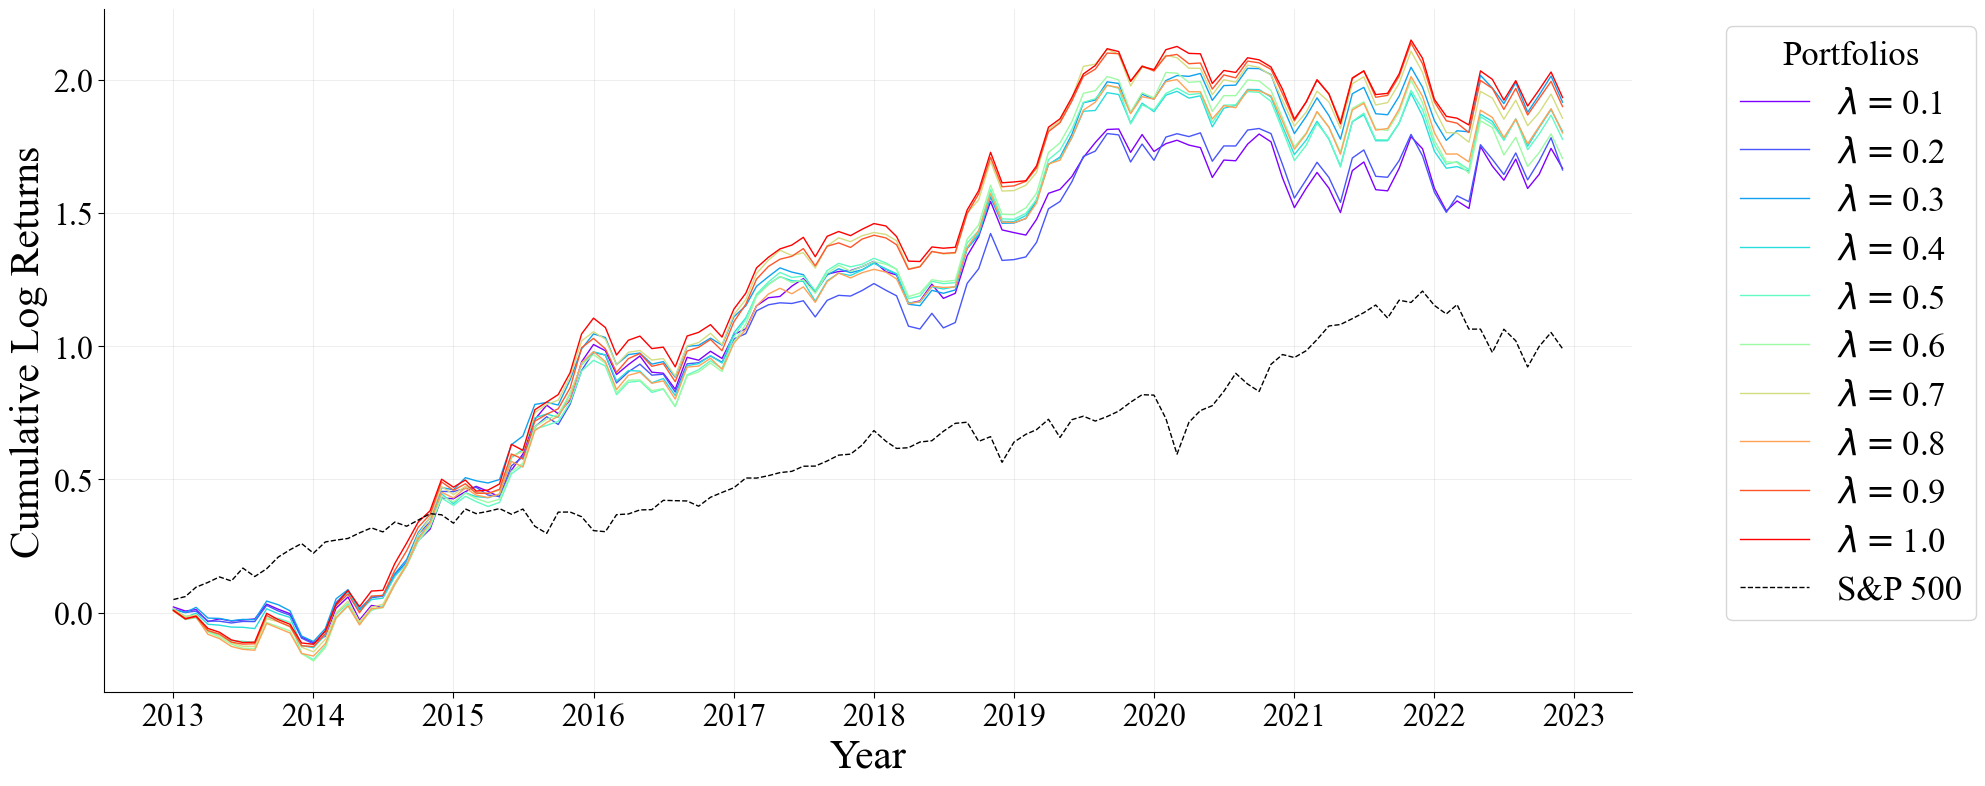

In [13]:
portfolio_summary_12_double = plot_portfolio_performance(
    horizon='12month',
    strategy='double_sort',
    weight_type='value',
    strategy_params={
        'upper_quantile_cons': 0.8,
        'lower_quantile_cons': 0.2,
        'upper_quantile_ret': 0.8,
        'lower_quantile_ret': 0.2,
        'sorting_sign': 'positive',
        'cons_var': 'Analyst earnings per share'
    },
    risk_free=risk_free, snp_500=snp_500, stock_info=stock_info
)

In [23]:
portfolio_analysis_12_double = calculate_portfolio_metrics(portfolio_summary_12_double)
portfolio_analysis_12_double

,mean return,std,cumulative return,Sharpe,max 1M loss,max DD,turnover
0.1,0.013890,0.068574,1.666821,0.763546,13.813757,26.914058,64.787200
0.2,0.013841,0.068278,1.660928,0.763917,12.763223,27.001843,62.514670
0.3,0.015960,0.068132,1.915201,0.894387,11.779777,23.988720,63.547680
0.4,0.015045,0.068347,1.805372,0.835704,12.426707,26.433424,64.746113
0.5,0.014800,0.070005,1.775960,0.801398,12.500077,27.189047,64.370911
0.6,0.014199,0.070208,1.703821,0.763784,13.137152,31.512975,64.403366
0.7,0.015456,0.069779,1.854705,0.843054,12.855753,29.432408,63.833066
0.8,0.015000,0.068503,1.799985,0.831079,12.781048,27.411434,64.277758
0.9,0.015823,0.069002,1.898780,0.874798,13.327903,28.536146,63.900144
1.0,0.016108,0.070361,1.932907,0.874860,14.311055,27.288987,64.041229


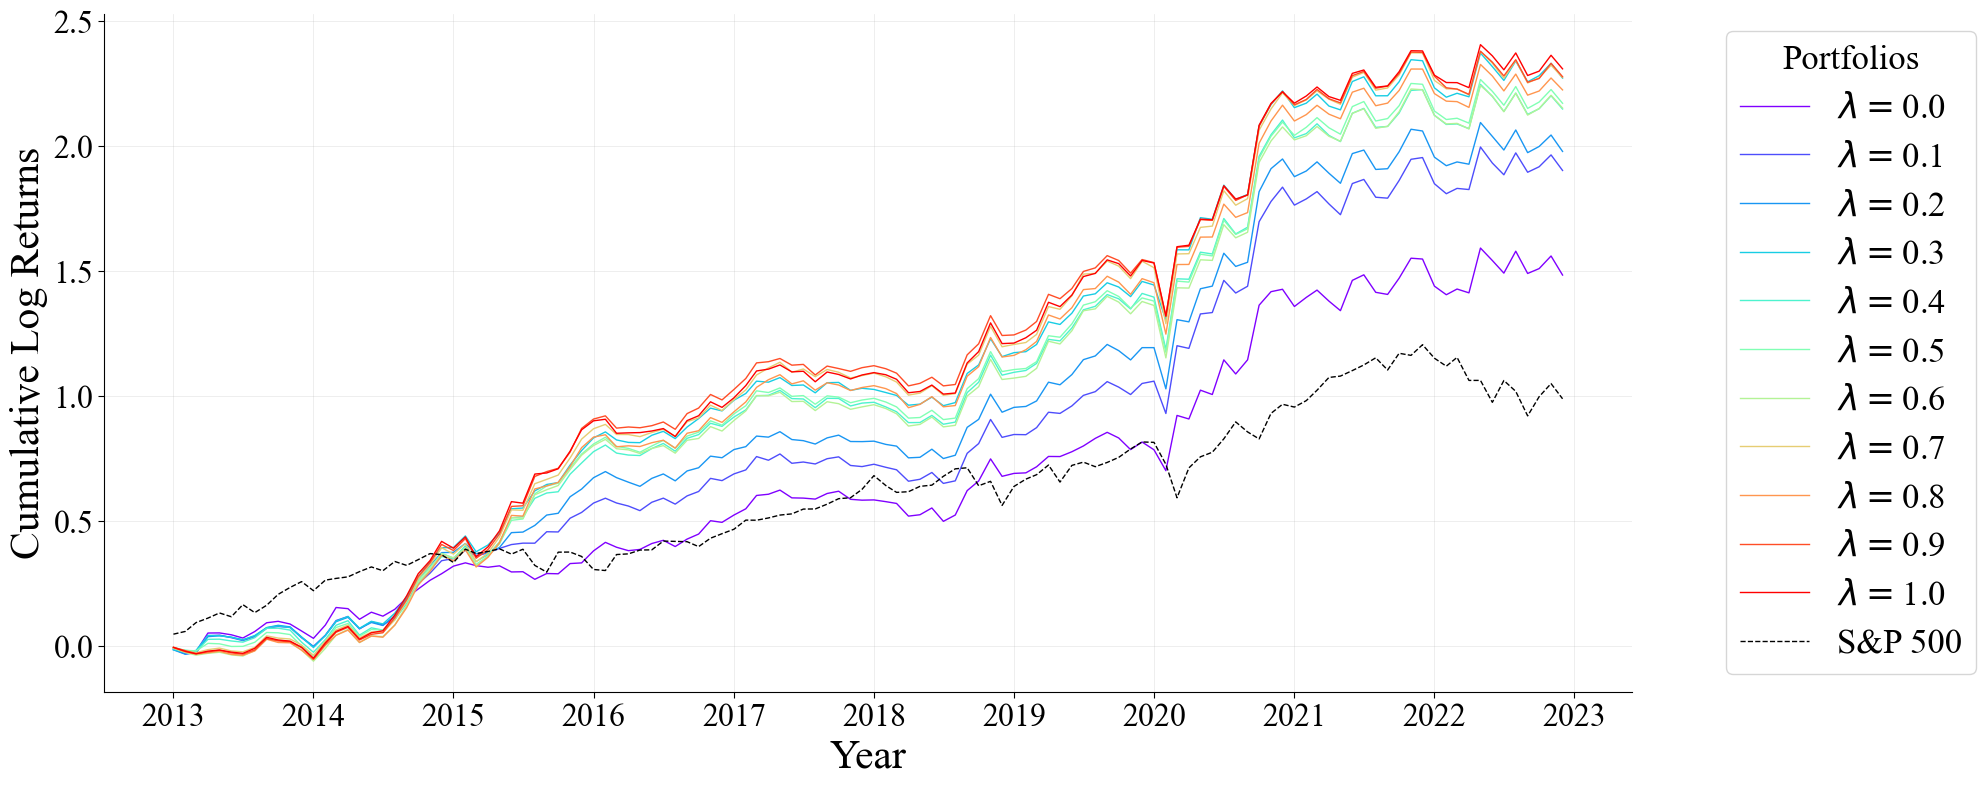

In [14]:
portfolio_summary_12_single_w_cost = plot_portfolio_performance(
    horizon='12month',
    strategy='single_sort',
    strategy_params={
        'upper_quantile': 0.9,
        'lower_quantile': 0.1
    },
    weight_type='value',
    risk_free=risk_free, snp_500=snp_500, stock_info=stock_info,
    transaction_cost=0.005 # 50 bps per unit of turnover
)

In [15]:
portfolio_analysis_12_single_w_cost = calculate_portfolio_metrics(portfolio_summary_12_single_w_cost)
portfolio_analysis_12_single_w_cost

,mean return,std,cumulative return,Sharpe,max 1M loss,max DD,turnover
0.0,0.012375,0.052805,1.485011,0.875201,10.269089,14.207865,58.286652
0.1,0.015859,0.057337,1.903109,1.055409,12.122601,13.457786,58.103473
0.2,0.016493,0.060002,1.979173,1.052967,15.191754,16.270358,58.833569
0.3,0.018936,0.060605,2.272353,1.215226,13.049490,14.281612,60.901628
0.4,0.017908,0.063260,2.148953,1.093973,18.883347,20.083562,61.096150
0.5,0.018097,0.063248,2.171667,1.107053,18.497524,21.810815,60.651463
0.6,0.017939,0.063637,2.152662,1.089582,18.915801,21.810003,60.996226
0.7,0.018954,0.064339,2.274526,1.145920,20.053482,22.142675,60.276922
0.8,0.018543,0.063218,2.225151,1.137999,18.578153,20.663493,60.614779
0.9,0.018983,0.063692,2.277966,1.159515,19.133076,21.355141,61.237938


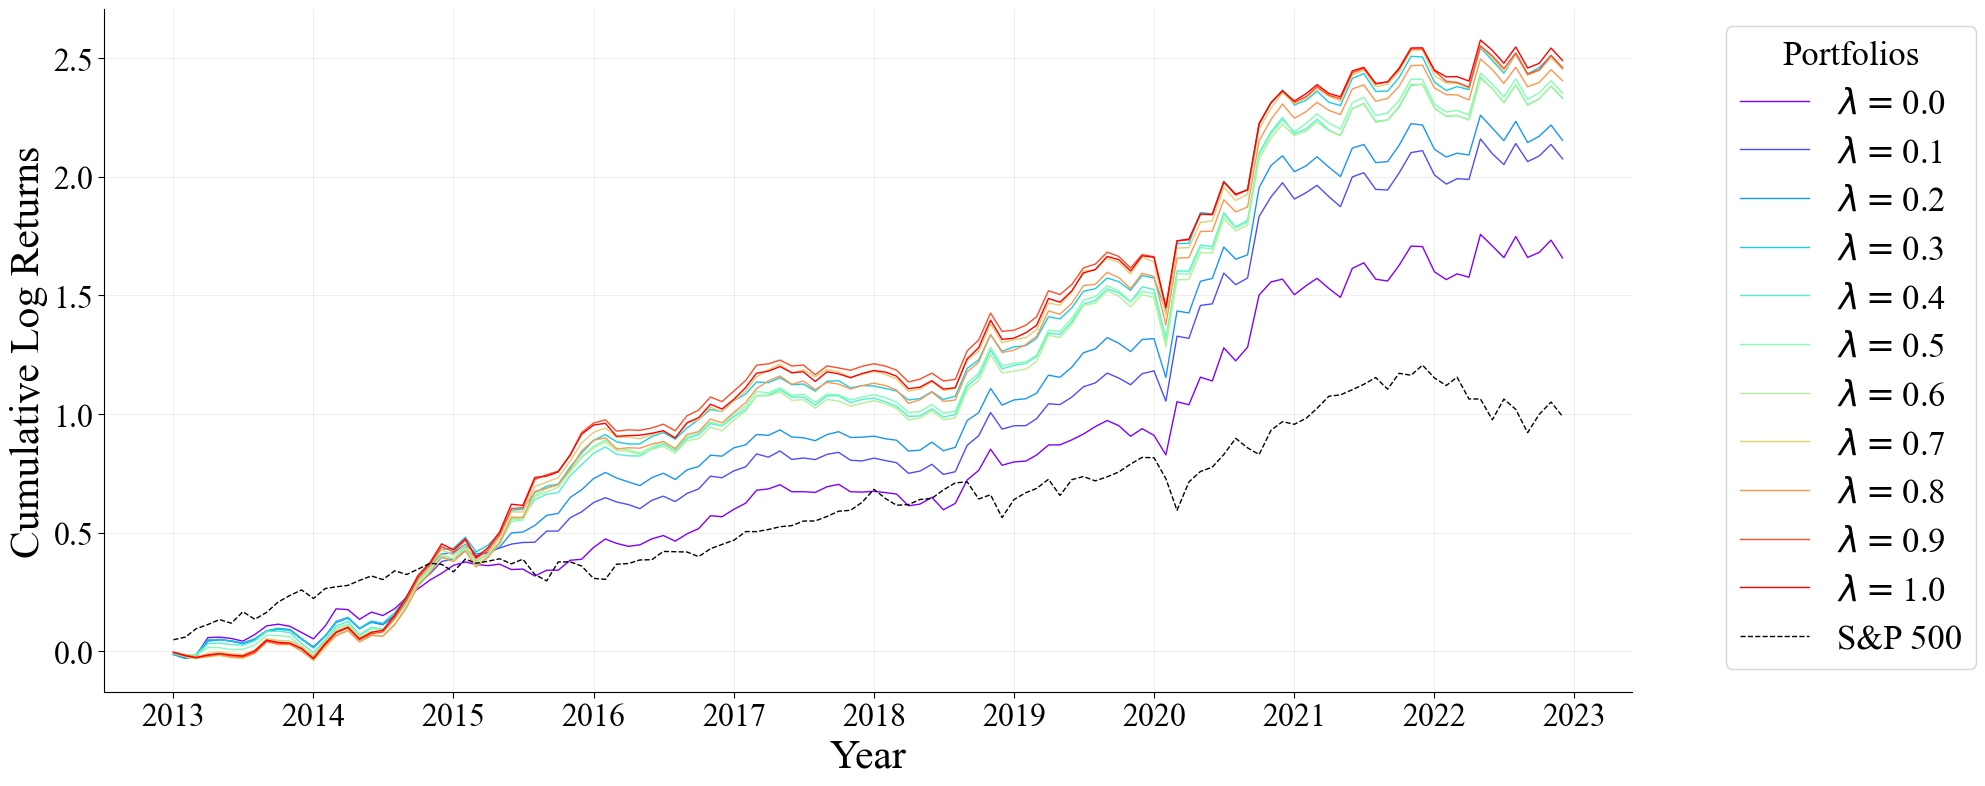

In [16]:
portfolio_summary_12_single_w_cost = plot_portfolio_performance(
    horizon='12month',
    strategy='single_sort',
    strategy_params={
        'upper_quantile': 0.9,
        'lower_quantile': 0.1
    },
    weight_type='value',
    risk_free=risk_free, snp_500=snp_500, stock_info=stock_info,
    transaction_cost=0.0025 # 25 bps per unit of turnover
)

In [17]:
portfolio_analysis_12_single_w_cost = calculate_portfolio_metrics(portfolio_summary_12_single_w_cost)
portfolio_analysis_12_single_w_cost

,mean return,std,cumulative return,Sharpe,max 1M loss,max DD,turnover
0.0,0.013820,0.052786,1.658414,0.986498,10.067461,13.456409,58.286652
0.1,0.017300,0.057332,2.075967,1.161687,12.009615,13.154691,58.103473
0.2,0.017952,0.059974,2.154203,1.157050,15.068850,15.446267,58.833569
0.3,0.020446,0.060568,2.453535,1.325337,12.917722,13.849964,60.901628
0.4,0.019423,0.063216,2.330714,1.198577,18.756045,19.668790,61.096150
0.5,0.019601,0.063210,2.352105,1.211039,18.372638,21.003590,60.651463
0.6,0.019451,0.063593,2.334126,1.193429,18.789088,21.000373,60.996226
0.7,0.020449,0.064292,2.453850,1.248747,19.937919,21.686831,60.276922
0.8,0.020046,0.063166,2.405480,1.242823,18.447638,19.846121,60.614779
0.9,0.020501,0.063644,2.460149,1.265110,19.005174,20.538799,61.237938


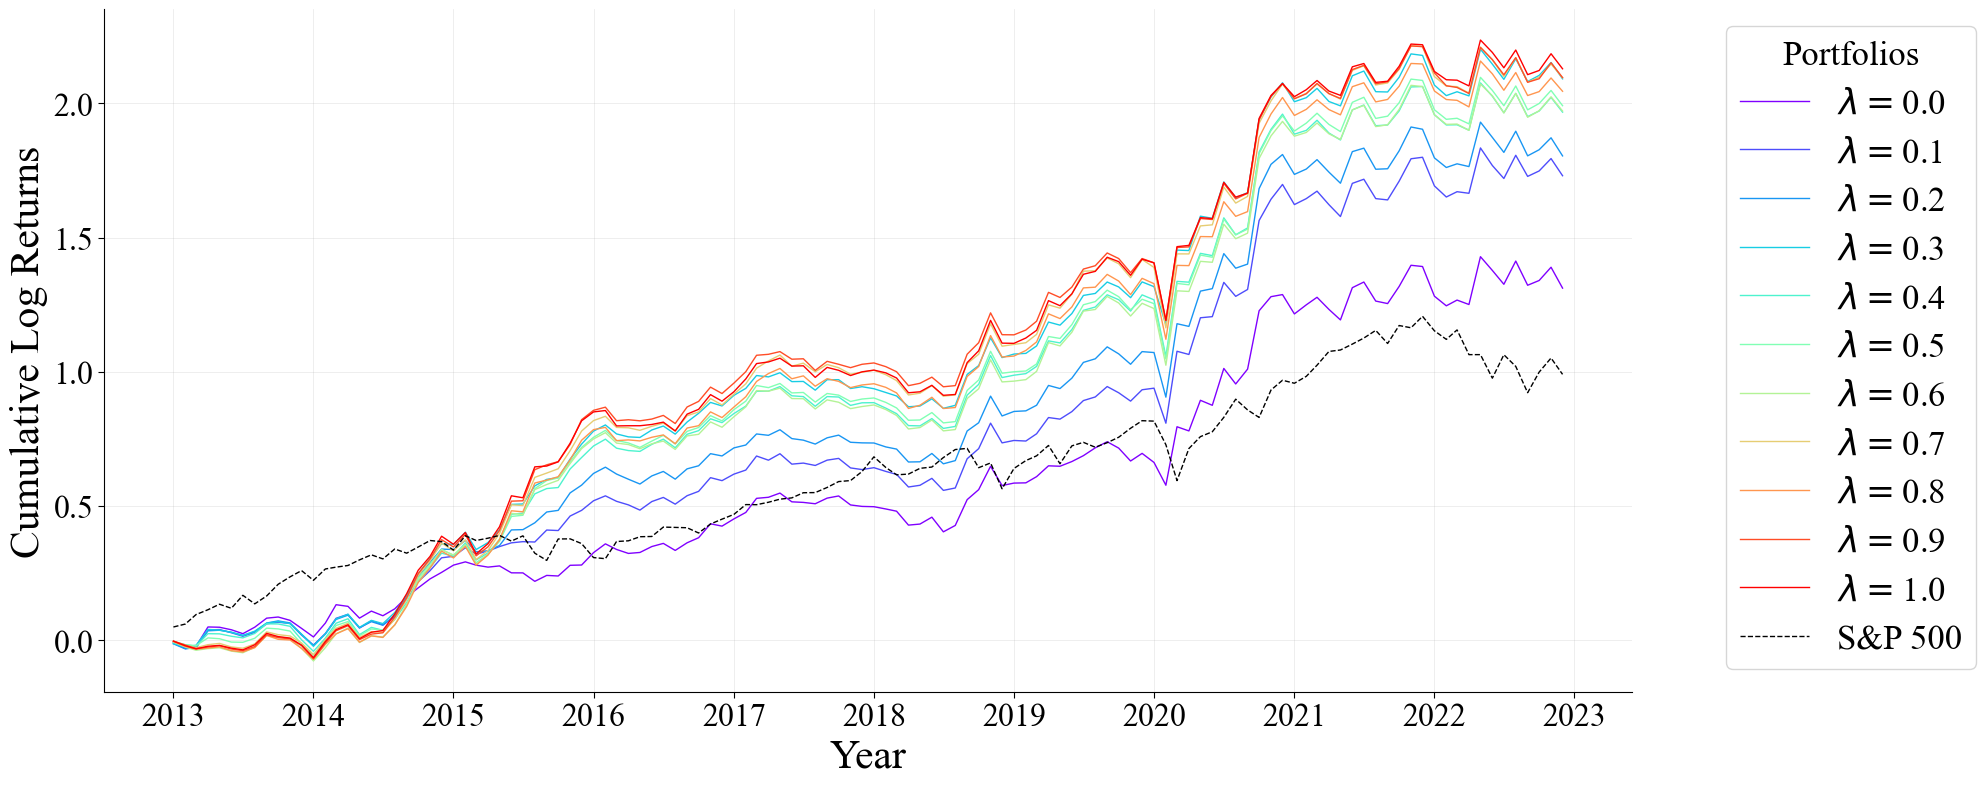

In [20]:
portfolio_summary_12_single_w_cost = plot_portfolio_performance(
    horizon='12month',
    strategy='single_sort',
    strategy_params={
        'upper_quantile': 0.9,
        'lower_quantile': 0.1
    },
    weight_type='value',
    risk_free=risk_free, snp_500=snp_500, stock_info=stock_info,
    transaction_cost=0.0075 # 75 bps per unit of turnover
)

In [21]:
portfolio_analysis_12_single_w_cost = calculate_portfolio_metrics(portfolio_summary_12_single_w_cost)
portfolio_analysis_12_single_w_cost

,mean return,std,cumulative return,Sharpe,max 1M loss,max DD,turnover
0.0,0.010930,0.052829,1.311608,0.765827,10.470265,14.952796,58.286652
0.1,0.014419,0.057345,1.730251,0.950897,12.235442,13.759824,58.103473
0.2,0.015035,0.060034,1.804144,0.950706,15.314480,17.086417,58.833569
0.3,0.017426,0.060646,2.091171,1.107117,13.181059,14.711098,60.901628
0.4,0.016393,0.063309,1.967192,0.991307,19.010448,20.512772,61.096150
0.5,0.016594,0.063290,1.991229,1.004960,18.622219,22.609790,60.651463
0.6,0.016427,0.063686,1.971198,0.987655,19.042317,22.611335,60.996226
0.7,0.017460,0.064390,2.095202,1.044977,20.168878,22.927827,60.276922
0.8,0.017040,0.063275,2.044822,1.035126,18.708459,21.472530,60.614779
0.9,0.017465,0.063745,2.095783,1.055886,19.260777,22.163097,61.237938


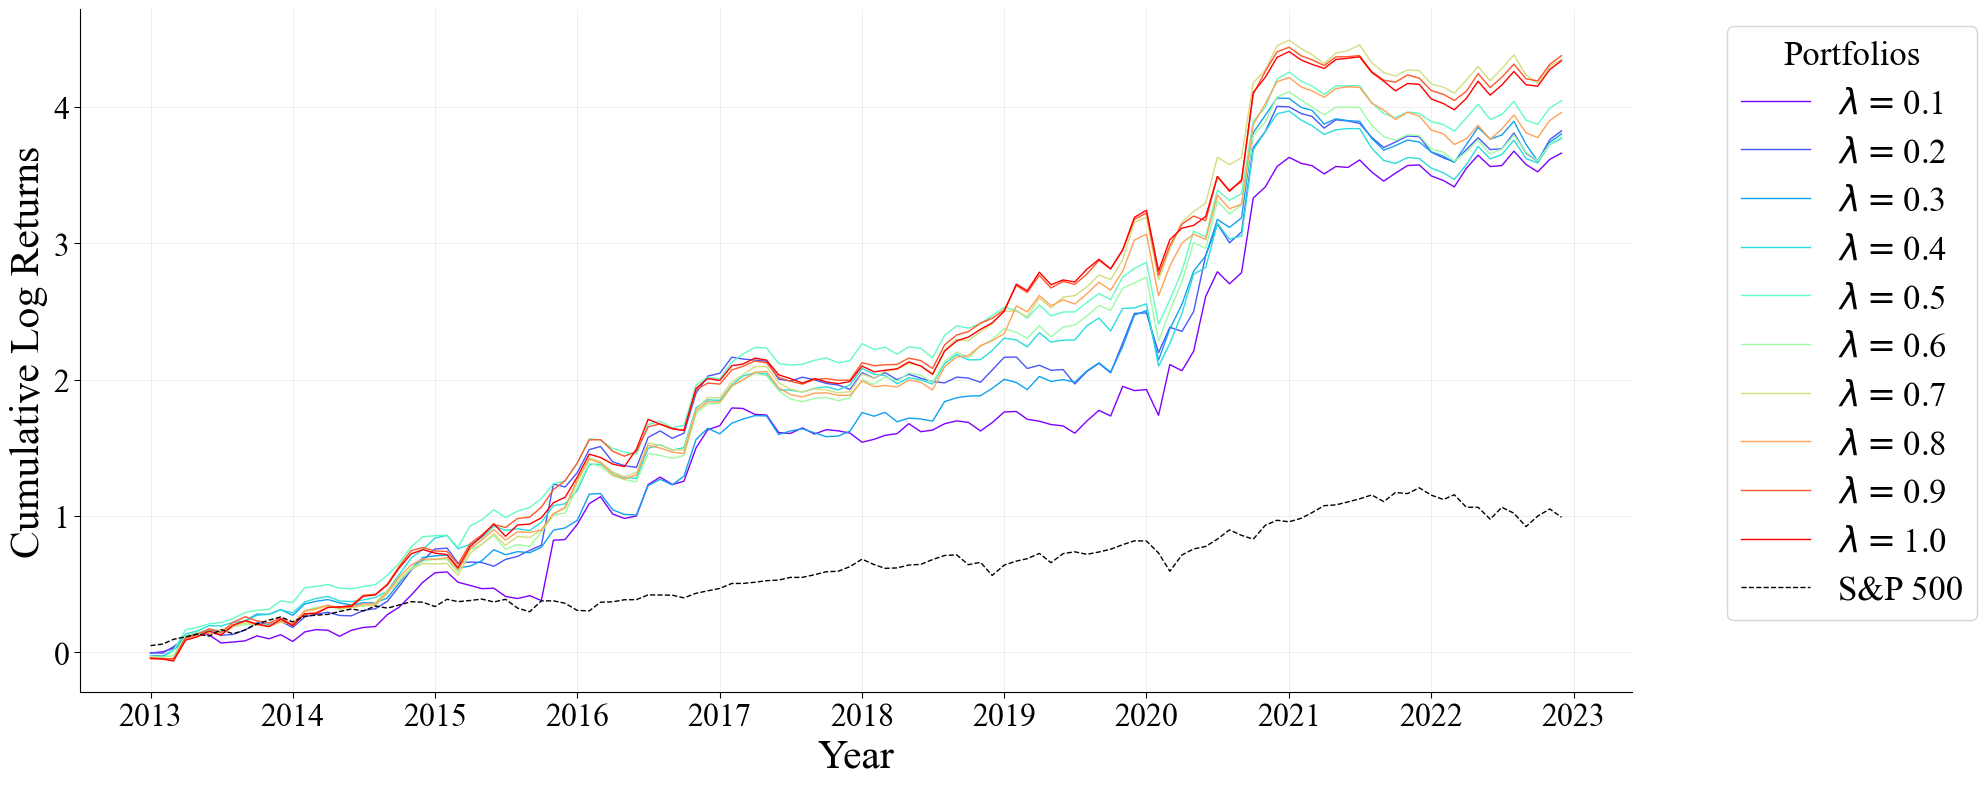

In [68]:
portfolio_summary_12_screening_neg = plot_portfolio_performance(
    horizon='12month',
    strategy='screening',
    weight_type='value',
    strategy_params={
        'cons_var': 'Analyst earnings per share',
        'cons_ref': 0.1,
        'sorting_sign': 'negative',
        'upper_quantile': 0.9,
        'lower_quantile': 0.1
    },
    risk_free=risk_free, snp_500=snp_500, stock_info=stock_info
)

In [69]:
portfolio_analysis_12_screening_neg = calculate_portfolio_metrics(portfolio_summary_12_screening_neg)
portfolio_analysis_12_screening_neg

,mean return,std,cumulative return,Sharpe,max 1M loss,max DD,turnover
0.1,0.030509,0.106117,3.661081,1.202699,17.219009,22.224145,75.274639
0.2,0.031864,0.113997,3.823678,1.179426,25.227785,33.510326,74.703404
0.3,0.031677,0.105711,3.801242,1.262900,30.456113,37.566971,75.279720
0.4,0.031398,0.109344,3.767748,1.208028,36.695592,39.476104,75.237589
0.5,0.033708,0.105918,4.044969,1.358770,36.474605,36.474605,75.434766
0.6,0.031491,0.107807,3.778971,1.229631,37.419042,39.909021,75.173683
0.7,0.036245,0.108136,4.349417,1.454573,36.872769,36.872769,73.578454
0.8,0.032989,0.109054,3.958726,1.285642,36.392473,38.833736,74.817921
0.9,0.036466,0.109256,4.375884,1.450480,36.739306,36.739306,74.972544
1.0,0.036153,0.110138,4.338316,1.423633,35.924974,35.924974,74.099490


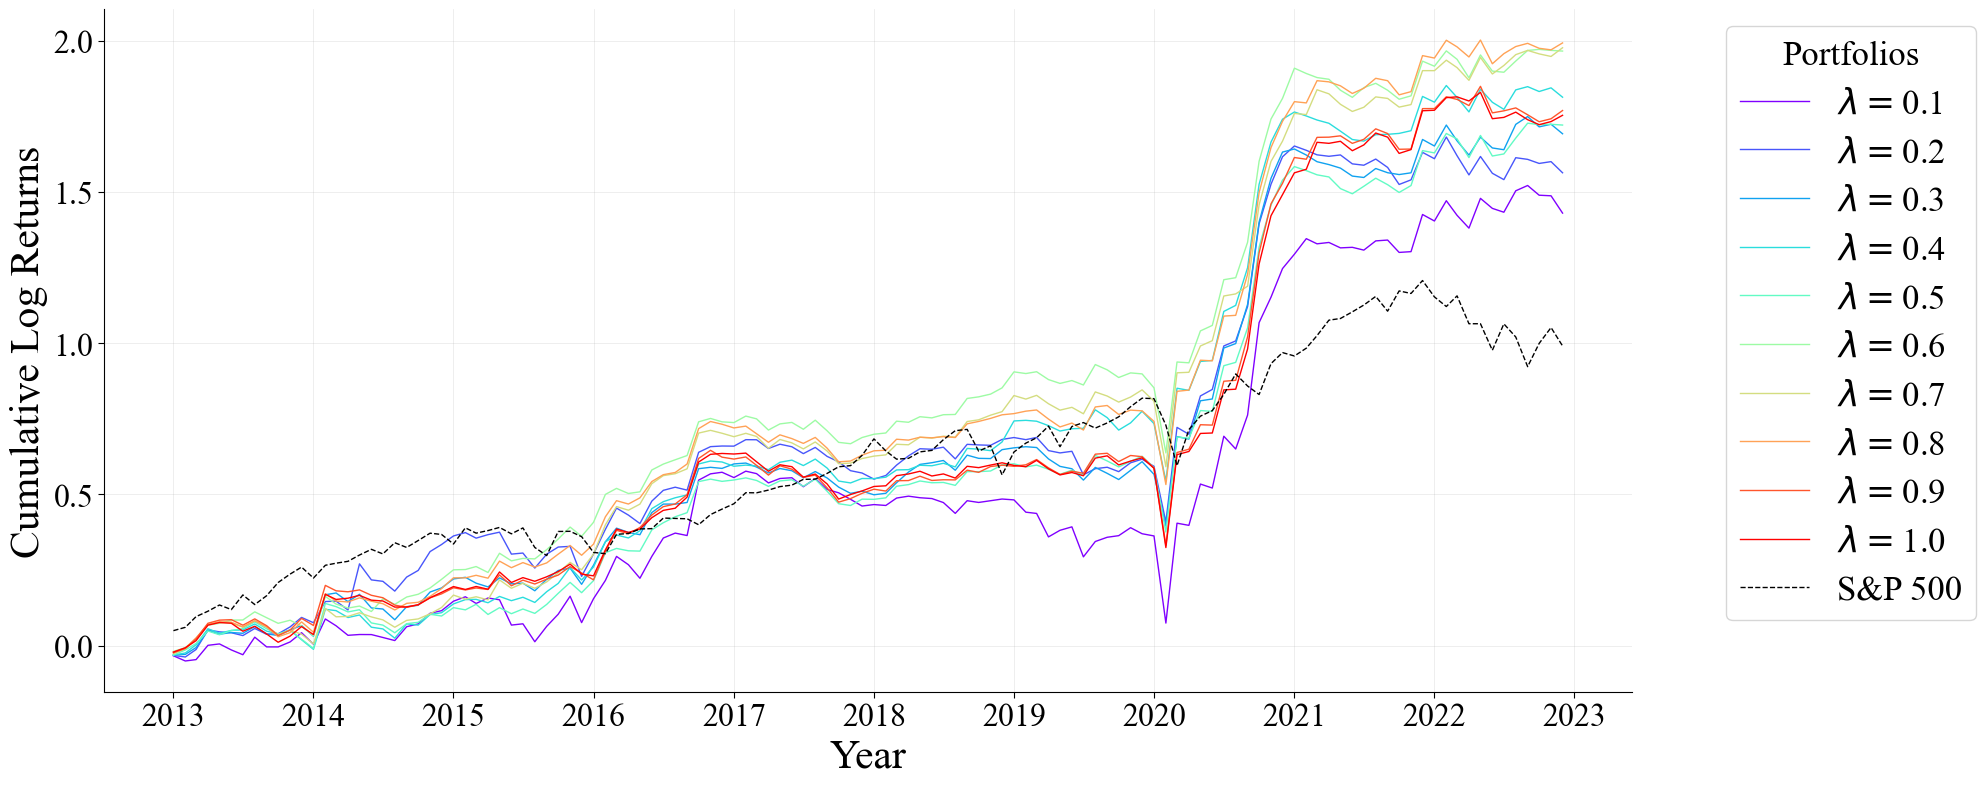

In [76]:
portfolio_summary_12_screening_neg = plot_portfolio_performance(
    horizon='12month',
    strategy='screening',
    weight_type='value',
    strategy_params={
        'cons_var': 'EPS Forecast Dispersion',
        'cons_ref': 0.9,
        'sorting_sign': 'negative',
        'upper_quantile': 0.9,
        'lower_quantile': 0.1
    },
    risk_free=risk_free, snp_500=snp_500, stock_info=stock_info
)

In [75]:
portfolio_analysis_12_screening_neg = calculate_portfolio_metrics(portfolio_summary_12_screening_neg)
portfolio_analysis_12_screening_neg

,mean return,std,cumulative return,Sharpe,max 1M loss,max DD,turnover
0.1,0.013213,0.068574,1.585511,0.723274,25.635114,37.129319,71.475126
0.2,0.012022,0.070318,1.442617,0.637086,28.730736,37.229480,70.013823
0.3,0.013648,0.066619,1.637777,0.771107,25.388196,30.794515,70.010574
0.4,0.015533,0.067835,1.863950,0.871959,25.665748,28.826298,70.683962
0.5,0.014820,0.065503,1.778374,0.857754,23.500621,30.108302,70.202390
0.6,0.015281,0.064810,1.833667,0.896419,24.340244,27.925074,70.950651
0.7,0.015312,0.065970,1.837387,0.882621,25.989937,29.617367,70.708653
0.8,0.015037,0.066270,1.804454,0.861406,25.871887,32.742874,71.002937
0.9,0.016254,0.066851,1.950473,0.930004,26.555902,34.571852,70.584830
1.0,0.015211,0.067013,1.825327,0.862647,27.399902,32.221347,70.189627
